## Cell 1 — Imports & Paths

In [ ]:
# Import standard libraries
import os, random, time, copy, shutil
os.environ['LOKY_MAX_CPU_COUNT'] = str(os.cpu_count())
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from PIL import Image
from datetime import datetime
from collections import Counter

# Import sklearn preprocessing tools
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

# Import PyTorch core libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.models as models
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Mount Google Drive for data access
from google.colab import drive
drive.mount('/content/drive')

# Set directory paths
BASE_DIR = '/content/drive/MyDrive/ELEC378FinalProject'
TRAIN_IMG_DIR = os.path.join(BASE_DIR, 'train_images')
CSV_PATH  = os.path.join(BASE_DIR, 'train.csv')
TEST_IMG_DIR = os.path.join(BASE_DIR, 'test_images')
SUBMISSION_PATH = os.path.join(BASE_DIR, 'outputs')
os.makedirs(SUBMISSION_PATH, exist_ok=True)

# Hyperparameters and normalization constants
IMG_SIZE = 224
RANDOM_STATE = 100
BATCH_SIZE = 64
EPOCHS = 160
START_EPOCH = 1
WARMUP_EP = 5
NORM_MEAN = [0.48386350274086, 0.4668925404548645, 0.3429041802883148]
NORM_STD = [0.2685154676437378, 0.2580546736717224, 0.2674645185470581]

# Set random seeds for reproducibility
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
torch.backends.cudnn.benchmark = True

# Check GPU availability
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Mounted at /content/drive
Device: cuda
GPU: NVIDIA A100-SXM4-40GB


## Cell 2 — Copy Data to Local SSD

In [ ]:
# Copy training and test data to local SSD
print('Copying data to local SSD...')
shutil.copytree('/content/drive/MyDrive/ELEC378FinalProject/train_images',
                '/content/train_images')
shutil.copytree('/content/drive/MyDrive/ELEC378FinalProject/test_images',
                '/content/test_images')
shutil.copy('/content/drive/MyDrive/ELEC378FinalProject/train.csv',
            '/content/train.csv')
print('Done')

# Update paths to local storage
TRAIN_IMG_DIR = '/content/train_images'
TEST_IMG_DIR = '/content/test_images'
CSV_PATH = '/content/train.csv'

Copying data to local SSD...
Done


## Cell 3 — Load CSV & Split

In [ ]:
# Load CSV and encode class labels
df = pd.read_csv(CSV_PATH)
le = LabelEncoder()
df['label_encoded'] = le.fit_transform(df['TARGET'])
NUM_CLASSES = len(le.classes_)
print(f'Classes: {NUM_CLASSES}  |  Total samples: {len(df)}')

# Stratified 80-20 train-validation split
X_files, X_val_files, y_train, y_val = train_test_split(
    df['file_name'].values,
    df['label_encoded'].values,
    test_size = 0.2,
    stratify = df['label_encoded'].values,
    random_state = RANDOM_STATE)

# Zip filenames with corresponding labels
train_samples = list(zip(X_files, y_train))
val_samples   = list(zip(X_val_files, y_val))
print(f'Train: {len(train_samples)}  |  Val: {len(val_samples)}')

Classes: 100  |  Total samples: 12594
Train: 10075  |  Val: 2519


## Cell 4 — Augmentation Transforms

In [ ]:
# Training transforms: resize, crop, flip, color jitter
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE + 32, IMG_SIZE + 32)),
    transforms.RandomResizedCrop(IMG_SIZE, scale = (0.6, 1.0),
                                 ratio = (0.75, 1.33)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(p = 0.1),
    transforms.ColorJitter(brightness = 0.3, contrast = 0.3, saturation = 0.3,
                           hue = 0.1),
    transforms.RandomGrayscale(p = 0.05),
    transforms.RandAugment(num_ops = 2, magnitude = 9),
    transforms.ToTensor(),
    transforms.Normalize(NORM_MEAN, NORM_STD),
    transforms.RandomErasing(p = 0.25, scale = (0.02, 0.2)),
])

# Validation transforms: resize and normalize only
val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(NORM_MEAN, NORM_STD),
])

# TTA: 10 crops (center, flip, 8 random)
tta_transforms = [
    transforms.Compose([transforms.Resize(256), transforms.CenterCrop(224),
                        transforms.ToTensor(),
                        transforms.Normalize(NORM_MEAN, NORM_STD)]),
    transforms.Compose([transforms.Resize(256), transforms.CenterCrop(224),
                        transforms.RandomHorizontalFlip(p = 1.0),
                        transforms.ToTensor(),
                        transforms.Normalize(NORM_MEAN, NORM_STD)]),] + [
    transforms.Compose([transforms.RandomResizedCrop(224, scale = (0.75, 1.0)),
                        transforms.ToTensor(),
                        transforms.Normalize(NORM_MEAN, NORM_STD)])
    for _ in range(8)]

## Cell 5 — Dataset & DataLoaders

In [ ]:
# Dataset for directory with CSV labels
class ButterflyDataset(Dataset):
    def __init__(self, samples, img_dir, transform=None):
        self.samples = samples
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        filename, label = self.samples[idx]
        img = Image.open(os.path.join(self.img_dir, filename)).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, label

# Compute class weights to balance training
label_counts   = Counter(y_train)
class_weights  = 1.0 / np.array([label_counts[i] for i in range(NUM_CLASSES)],
                                dtype = float)
sample_weights = torch.tensor([class_weights[lbl] for _, lbl in train_samples],
                              dtype = torch.double)

# Weighted sampler for class-balanced batches
sampler = WeightedRandomSampler(sample_weights, num_samples = len(sample_weights),
                                replacement = True)

# Create train and validation DataLoaders
train_loader = DataLoader(
    ButterflyDataset(train_samples, TRAIN_IMG_DIR, train_transform),
    batch_size = BATCH_SIZE, sampler = sampler, num_workers = 4, pin_memory = True)

val_loader = DataLoader(
    ButterflyDataset(val_samples, TRAIN_IMG_DIR, val_transform),
    batch_size = BATCH_SIZE, shuffle = False, num_workers = 4, pin_memory = True)

print(f'Train batches: {len(train_loader)}  |  Val batches: {len(val_loader)}')

Train batches: 158  |  Val batches: 40


## Cell 6 — MixUp & CutMix

In [ ]:
# MixUp: linear blend of two image pairs
def mixup(x, y, alpha=0.4):
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(x.size(0), device = x.device)
    return lam * x + (1 - lam) * x[idx], y, y[idx], lam


# CutMix: paste random region from shuffled image
def cutmix(x, y, alpha = 1.0):
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(x.size(0), device = x.device)
    W, H = x.size(3), x.size(2)
    cut_w = int(W * np.sqrt(1 - lam))
    cut_h = int(H * np.sqrt(1 - lam))
    cx, cy = np.random.randint(W), np.random.randint(H)
    x1 = np.clip(cx - cut_w // 2, 0, W)
    y1 = np.clip(cy - cut_h // 2, 0, H)
    x2 = np.clip(cx + cut_w // 2, 0, W)
    y2 = np.clip(cy + cut_h // 2, 0, H)
    x_cut = x.clone()
    x_cut[:, :, y1:y2, x1:x2] = x[idx, :, y1:y2, x1:x2]
    lam = 1 - (x2 - x1) * (y2 - y1) / (W * H)
    return x_cut, y, y[idx], lam


# Weighted loss for mixed labels
def mixed_loss(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

## Cell 7 — ResNet50 Architecture

In [ ]:
# Build ResNet50 from torchvision with zero-init residual BN
def build_resnet50(num_classes, dropout = 0.3):
    m = models.resnet50(weights = None, zero_init_residual = True)

    # Replace FC with dropout and custom-class linear head
    m.fc = nn.Sequential(nn.Dropout(dropout), nn.Linear(2048, num_classes))
    return m

# Initialize model and move to GPU
model = build_resnet50(NUM_CLASSES).to(DEVICE)
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')

Parameters: 23,712,932


## Cell 8 — Loss, SAM Optimizer & Scheduler

In [ ]:
# SAM optimizer: perturbs weights toward sharpest ascent to find flat minima
class SAM(torch.optim.Optimizer):
    def __init__(self, params, base_optimizer, rho=0.05, **kwargs):
        super().__init__(params, dict(rho=rho, **kwargs))
        self.base_optimizer = base_optimizer(self.param_groups, **kwargs)
        self.param_groups   = self.base_optimizer.param_groups

    # Compute global grad norm and perturb weights toward ascent direction
    @torch.no_grad()
    def first_step(self, zero_grad = False):
        grad_norm = torch.stack([
            p.grad.norm(2) for g in self.param_groups
            for p in g['params'] if p.grad is not None]).norm(2)
        for group in self.param_groups:
            scale = group['rho'] / (grad_norm + 1e-12)
            for p in group['params']:
                if p.grad is None: continue
                e_w = p.grad * scale
                p.add_(e_w)
                self.state[p]['e_w'] = e_w
        if zero_grad: self.zero_grad()

    # Undo perturbation and take base optimizer step
    @torch.no_grad()
    def second_step(self, zero_grad = False):
        for group in self.param_groups:
            for p in group['params']:
                if p.grad is None: continue
                p.sub_(self.state[p]['e_w'])
        self.base_optimizer.step()
        if zero_grad: self.zero_grad()

    # Undo perturbation without updating (used on NaN second pass)
    @torch.no_grad()
    def restore_weights(self):
        for group in self.param_groups:
            for p in group['params']:
                if 'e_w' in self.state[p]:
                    p.sub_(self.state[p]['e_w'])
        self.zero_grad()

    def step(self, closure = None): pass

# Built-in label smoothing cross-entropy loss
criterion = nn.CrossEntropyLoss(label_smoothing = 0.1)

# SAM wraps SGD; base lr=0.01, warmup ramps to 0.05
optimizer = SAM(model.parameters(), optim.SGD, lr = 0.01, momentum = 0.9,
                weight_decay = 5e-4, nesterov = True)

# Linear warmup learning rates for first epochs
WARMUP_LRS = [0.01, 0.02, 0.03, 0.04, 0.05]

# Cosine annealing with warm restarts after warmup
cosine_sched = optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer.base_optimizer, T_0 = 20, T_mult = 2, eta_min = 1e-5)

## Cell 9 — Train & Validate

In [ ]:
# Reinitialize model for fresh training run
model = build_resnet50(NUM_CLASSES).to(DEVICE)
print(f'Model reinitialised — parameters: {sum(p.numel() for
                                               p in model.parameters()):,}')

# Setup loss, SAM optimizer, scheduler with tuned LR
criterion = nn.CrossEntropyLoss(label_smoothing = 0.1)
optimizer = SAM(model.parameters(), optim.SGD,
                   lr = 0.1, momentum = 0.9, weight_decay = 5e-4, nesterov = True)
WARMUP_LRS = [0.02, 0.04, 0.06, 0.08, 0.10]
cosine_sched = optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer.base_optimizer, T_0 = 20, T_mult = 2, eta_min = 1e-5)

# Adjust learning rate across SAM param groups
def set_lr(optimizer, lr):
    for group in optimizer.base_optimizer.param_groups:
        group['lr'] = lr

# Detect NaN or Inf gradients anywhere in the model
def has_nan_grad(model):
    return any(
        p.grad is not None and (torch.isnan(p.grad).any() or torch.isinf(p.grad).any())
        for p in model.parameters()
    )

# Training loop: SAM two-pass with MixUp/CutMix augmentation
def train_one_epoch(model, loader):
    model.train()
    total_loss = correct = total = skipped = 0

    for imgs, labels in tqdm(loader, desc = 'Train', leave = False):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)

        # Randomly apply MixUp or CutMix on half the batches
        mix_fn = None
        if random.random() > 0.5:
            mix_fn = mixup if random.random() > 0.5 else cutmix
            imgs, y_a, y_b, lam = mix_fn(imgs, labels)
        else:
            y_a, y_b, lam = labels, labels, 1.0

        # SAM pass 1
        optimizer.zero_grad()
        with torch.autocast('cuda', dtype=torch.bfloat16):
            out  = model(imgs)
            loss = mixed_loss(criterion, out, y_a, y_b, lam) if mix_fn else criterion(out, labels)

        # Skip batch if forward produced NaN/Inf
        if torch.isnan(loss) or torch.isinf(loss):
            skipped += 1
            continue

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm = 1.0)

        # Skip if gradients are NaN/Inf
        if has_nan_grad(model):
            optimizer.zero_grad()
            skipped += 1
            continue

        optimizer.first_step(zero_grad=True)

        # SAM pass 2
        with torch.autocast('cuda', dtype=torch.bfloat16):
            out2  = model(imgs)
            loss2 = mixed_loss(criterion, out2, y_a, y_b, lam) if mix_fn else criterion(out2, labels)

        # Restore weights to avoid corrupting model
        if torch.isnan(loss2) or torch.isinf(loss2):
            optimizer.restore_weights()
            skipped += 1
            continue

        loss2.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        # Restore weights if second-pass gradients are bad
        if has_nan_grad(model):
            optimizer.restore_weights()
            skipped += 1
            continue

        optimizer.second_step(zero_grad=True)

        # Accumulate training metrics
        total_loss += loss.item() * imgs.size(0)
        correct    += (out.argmax(1) == labels).sum().item()
        total      += imgs.size(0)

    # Report any skipped batches this epoch
    if skipped:
        print(f'    Skipped {skipped} batches due to NaN/inf', flush = True)
    if total == 0:
        return float('nan'), 0.0
    return total_loss / total, correct / total

# Validation loop without gradient tracking
@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total_loss = correct = total = 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)

        # Forward pass with bfloat16 autocast
        with torch.autocast('cuda', dtype = torch.bfloat16):
            out = model(imgs)
        total_loss += criterion(out, labels).item() * imgs.size(0)
        correct += (out.argmax(1) == labels).sum().item()
        total += imgs.size(0)
    return total_loss / total, correct / total

# Main training loop with warmup then cosine annealing
histor = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_acc = 0.0
best_weights = None

for epoch in range(START_EPOCH, START_EPOCH + EPOCHS):
    t0 = time.time()

    # Linear warmup for first WARMUP_EP epochs
    if epoch <= WARMUP_EP:
        set_lr(optimizer, WARMUP_LRS[epoch - 1])
    else:
        cosine_sched.step(epoch - WARMUP_EP)

    # Train and validate this epoch
    tr_loss, tr_acc = train_one_epoch(model, train_loader)
    vl_loss, vl_acc = evaluate(model, val_loader)

    # Stop if training loss is NaN
    if tr_loss != tr_loss:
        print('NaN in train loss — stopping')
        break

    # Record metrics for this epoch
    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(vl_acc)

    # Save best model when val accuracy improves
    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        best_weights = copy.deepcopy(model.state_dict())
        torch.save(best_weights, 'best_model.pth')
        shutil.copy('best_model.pth',
                    '/content/drive/MyDrive/ELEC378FinalProject/best_model.pth')
        print(f'  *** New best: {best_val_acc:.4f} — saved to Drive ***')

    # Print epoch summary
    lr = optimizer.base_optimizer.param_groups[0]['lr']
    print(f'Ep {epoch:3d}/{START_EPOCH + EPOCHS - 1} | '
          f'Loss {tr_loss:.3f}/{vl_loss:.3f} | '
          f'Acc {tr_acc:.3f}/{vl_acc:.3f} | '
          f'LR {lr:.5f} | {time.time()-t0:.1f}s')

print(f'\nBest validation accuracy: {best_val_acc:.4f}')

Model reinitialised — parameters: 23,712,932


  *** New best: 0.1068 — saved to Drive ***
Ep   1/160 | Loss 4.483/4.086 | Acc 0.038/0.107 | LR 0.02000 | 57.4s


  *** New best: 0.1612 — saved to Drive ***
Ep   2/160 | Loss 4.284/3.814 | Acc 0.062/0.161 | LR 0.04000 | 31.5s


Ep   3/160 | Loss 4.201/3.716 | Acc 0.074/0.156 | LR 0.06000 | 31.2s


  *** New best: 0.1977 — saved to Drive ***
Ep   4/160 | Loss 4.098/3.529 | Acc 0.090/0.198 | LR 0.08000 | 31.5s


...

Ep 156/160 | Loss 1.794/1.450 | Acc 0.708/0.822 | LR 0.09884 | 30.4s


Ep 157/160 | Loss 1.796/1.451 | Acc 0.684/0.811 | LR 0.09862 | 30.5s


Ep 158/160 | Loss 1.759/1.412 | Acc 0.709/0.833 | LR 0.09838 | 30.3s


Ep 159/160 | Loss 1.794/1.400 | Acc 0.680/0.828 | LR 0.09812 | 30.5s


Ep 160/160 | Loss 1.767/1.379 | Acc 0.713/0.847 | LR 0.09785 | 29.9s

Best validation accuracy: 0.9428


## Cell 10 — Training Curves

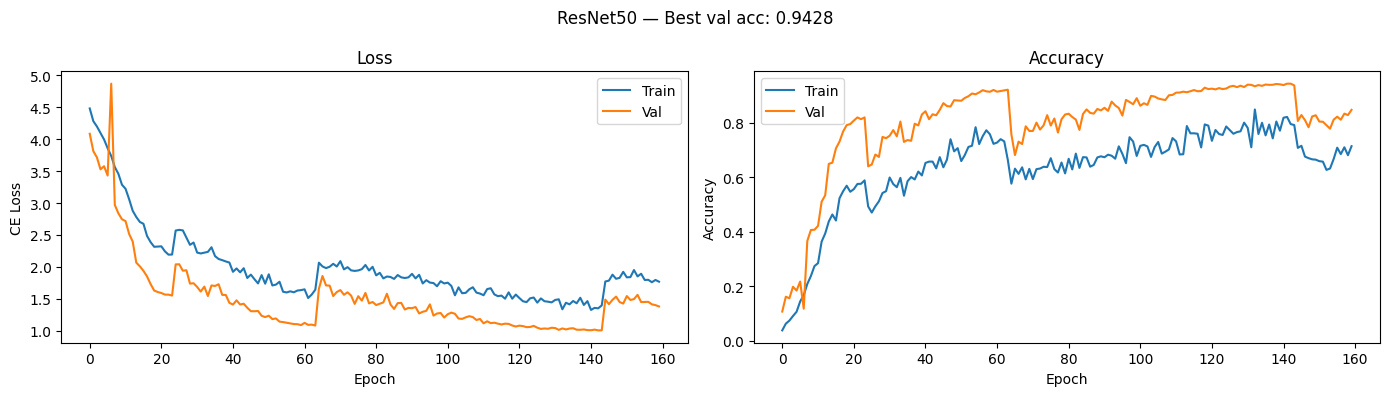

In [ ]:
# Create figure with side-by-side subplots
fig, axes = plt.subplots(1, 2, figsize = (14, 4))

# Plot training and validation loss curves
axes[0].plot(history['train_loss'], label = 'Train')
axes[0].plot(history['val_loss'],   label = 'Val')
axes[0].set(title = 'Loss', xlabel = 'Epoch', ylabel = 'CE Loss')
axes[0].legend()

# Plot accuracy curves
axes[1].plot(history['train_acc'], label = 'Train')
axes[1].plot(history['val_acc'],   label = 'Val')
axes[1].set(title = 'Accuracy', xlabel = 'Epoch', ylabel = 'Accuracy')
axes[1].legend()

# Finalize and display the figure
plt.suptitle(f'ResNet50 — Best val acc: {best_val_acc:.4f}')
plt.tight_layout()
plt.show()

## Cell 11 — Predict Test Set & Save submission.csv

In [ ]:
# Rebuild model and load best checkpoint for inference
model = build_resnet50(NUM_CLASSES).to(DEVICE)
model.load_state_dict(torch.load('best_model.pth', map_location = DEVICE))
model.eval()

# Test-time augmentation: average softmax over 10 crops
@torch.no_grad()
def predict_tta(img_path):
    img = Image.open(img_path).convert('RGB')
    probs = torch.zeros(NUM_CLASSES, device = DEVICE)

    # Forward pass through each TTA transform
    for t in tta_transforms:
        with torch.autocast('cuda', dtype = torch.bfloat16):
            x = t(img).unsqueeze(0).to(DEVICE)

            # Cast to float32 before softmax for stability
            probs += F.softmax(model(x)[0].float(), dim = 0)

    # Return class with highest averaged probability
    pred_idx = probs.argmax().item()
    return le.inverse_transform([pred_idx])[0]


# Collect sorted list of test image files
test_files = sorted([f for f in os.listdir(TEST_IMG_DIR) if f.endswith('.jpg')])
print(f'Test images: {len(test_files)}')

# Run TTA prediction on every test image
ids = [f.replace('.jpg', '') for f in test_files]
targets = [predict_tta(os.path.join(TEST_IMG_DIR, f)) for f in tqdm(test_files, desc='Predicting test set')]

# Save timestamped submission CSV to Drive
os.makedirs(SUBMISSION_PATH, exist_ok = True)
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
submission_file = os.path.join(SUBMISSION_PATH, f'submission_resnet50_{timestamp}.csv')
df_out = pd.DataFrame({'ID': ids, 'TARGET': targets})
df_out.to_csv(submission_file, index = False)

print(f'Saved: {submission_file}')
df_out.head(10)

Test images: 1000


Predicting test set: 100%|██████████| 1000/1000 [02:05<00:00,  7.98it/s]

Saved: /content/drive/MyDrive/ELEC378FinalProject/outputs/submission_resnet50_20260423_184657.csv


,ID,TARGET
0,test_000001,ADONIS
1,test_000002,ADONIS
2,test_000003,ADONIS
3,test_000004,ADONIS
4,test_000005,ADONIS
5,test_000006,ADONIS
6,test_000007,ADONIS
7,test_000008,ADONIS
8,test_000009,ADONIS
9,test_000010,ADONIS
